# Imports & Initializations

In [86]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt


DF_MESTA = pd.read_csv(
    'data/slovensko.csv',
    sep=','
)
M = len(DF_MESTA)
SUCET_POPULACIE = DF_MESTA['Population'].sum()
DF_MESTA['Weight'] = DF_MESTA['Population'] / SUCET_POPULACIE

DF_MESTA['geometry'] = [Point(xy) for xy in zip(DF_MESTA['Longitude'], DF_MESTA['Latitude'])]

DF_MESTA = gpd.GeoDataFrame(DF_MESTA, geometry='geometry', crs='EPSG:4326')
DF_MESTA = DF_MESTA.to_crs(epsg=5514)
# DF_MESTA['Points'] = DF_MESTA.geometry.apply(lambda p: [p.x, p.y]).to_numpy()

COORDS = np.column_stack([
    DF_MESTA.geometry.x,
    DF_MESTA.geometry.y,
])

WEIGHTS = DF_MESTA['Weight'].to_numpy()[:, None]

def plot_slovakia(point=None):
    slovakia = gpd.read_file(
        "data/ne_10m_admin_0_countries.zip"
    )

    slovakia = slovakia[slovakia["ISO_A3"] == "SVK"]
    slovakia = slovakia.to_crs(epsg=5514)


    fig, ax = plt.subplots(figsize=(10,8))

    slovakia.plot(
        ax=ax,
        color='whitesmoke',
        edgecolor='black'
    )

    DF_MESTA.plot(
        ax=ax,
        color='red',
        markersize=np.sqrt(DF_MESTA['Population']) / 5,
        alpha=0.7
    )

    if point is not None:
        ax.scatter(point[0], point[1], s=160, color="green", marker="x", zorder=5)

    for x,y,city in zip(DF_MESTA.geometry.x, DF_MESTA.geometry.y, DF_MESTA['City']):
        ax.text(x,y,city, fontsize=8, ha='left', va='bottom')

    ax.set_axis_off()

    plt.tight_layout()
    plt.show()
    

In [87]:
# print(world.columns)
# print(world[["ADMIN", "NAME", "SOVEREIGNT"]].head())
# print(world[world.astype(str).apply(lambda row: row.str.contains("Slovak", case=False).any(), axis=1)])
minx, miny, maxx, maxy = slovakia.total_bounds
print(minx, miny, maxx, maxy)

-590652.5286587091 -1332129.299685621 -167392.0486879384 -1134004.867050719


# Uloha a)



Mame funkciu
$$
f(x) = \sum_{i=1}^m w_i \|x-a^i\|_2
$$

kde $m$ je pocet miest, $w_i$ je vaha pridelena $i$-temu mestu a $a^i$ su 2d suradnice $i$-teho miesta 
***
Oznacme si
$$
\begin{aligned}
u_i &= x_1 - a_1^i \\
v_i &= x_2 - a_2^i \\
d_i(x) &= \sqrt{u_i^2 + v_i^2} = \|x-a^i\|_2
\end{aligned}
$$

Gradient tejto funkcie
$$

\nabla f(x) = 
\begin{pmatrix}
\displaystyle \sum_{i=1}^m w_i \frac{u_i}{d_i(x)} \\
\displaystyle \sum_{i=1}^m w_i \frac{v_i}{d_i(x)}
\end{pmatrix}
$$
V kompaktnej forme
$$
\nabla f(x) = \displaystyle \sum_{i=1}^m w_i \frac{x-a^i}{\|x-a^i\|_2}
$$

Hesseho matica
$$
\nabla^2 f(x) = 
\displaystyle \sum_{i=1}^m w_i
\begin{pmatrix}
\frac{1}{d_i} - \frac{u_i^2}{d_i^3} & -\frac{u_iv_i}{d_i^3} \\
-\frac{u_iv_i}{d_i^3} & \frac{1}{d_i} - \frac{v_i^2}{d_i^3}
\end{pmatrix}
$$

V kompaktnej forme:
$$
\nabla^2 f(x) = \displaystyle \sum_{i=1}^m w_i \left[ \frac{1}{\|x-a^i\|_2}I - \frac{(x-a^i)(x-a^i)^\top}{\|x-a^i\|^3_2} \right]
$$

# Uloha b)

**Globalne minimum existuje**: Majme hodnoty 
$$
a = min(a_1^i) \forall i \\
b = max(a_1^i) \forall i \\
c = min(a_2^i) \forall i \\
d = max(a_2^i) \forall i 
$$

Potom z tychto bodov vytvorme obdlznik s vrcholmi 
$$
[a,c], [a,d], [b,c], [b,d]
$$

Ak mame bod mimo tochto obdlznika, urcite to nebude minimum funkcie, lebo sa mozeme posunut, k najblizsiemu bodu na hrane tochto obdlznika, cim hodnotu funkcie znizime. Tym padom, ak globalne minimum existuje, musi sa nachadzat v tomto obdlzniku. 

Tento obdlznik je uzavrety a funkcia je spojita, preto mozeme pouzit Weierstrassovu vetu o extreme, ktora hovori, ze v tejto oblasti funkcia nadobudne minimum, a toto bude aj nase hladane globalne minimum.


**Riesenie nie je vo vseobecnosti jednoznacne**. Uvazujume priklad, v ktorom mame 2 mesta s rovnakym poctom obyvatelov. V takom pripade mame rovnaku hodnotu funkcie na celej usecke medzi tymito bodmi.

# Uloha c)

$$
\nabla f(x) = \displaystyle \sum_{i=1}^m w_i \frac{x-a^i}{\|x-a^i\|_2} = 0
$$



$$
\displaystyle \sum_{i=1}^m w_i \frac{x}{\|x-a^i\|_2} 
- \sum_{i=1}^m w_i \frac{a^i}{\|x-a^i\|_2} = 0
$$

$$
\displaystyle \sum_{i=1}^m w_i \frac{x}{\|x-a^i\|_2} = \sum_{i=1}^m w_i \frac{a^i}{\|x-a^i\|_2}
$$

$$
\left( \displaystyle \sum_{i=1}^m \frac{w_i}{\|x-a^i\|_2} \right) x = \sum_{i=1}^m w_i \frac{a^i}{\|x-a^i\|_2}
$$

$$
x = \frac{\displaystyle \sum_{i=1}^m \frac{w_i a^i}{\|x-a^i\|_2}}{\displaystyle \sum_{i=1}^m \frac{w_i}{\|x-a^i\|_2}}
$$

# Uloha d)

Finished in 69 iterations, found: [ -461685.1411152  -1236579.05467424]


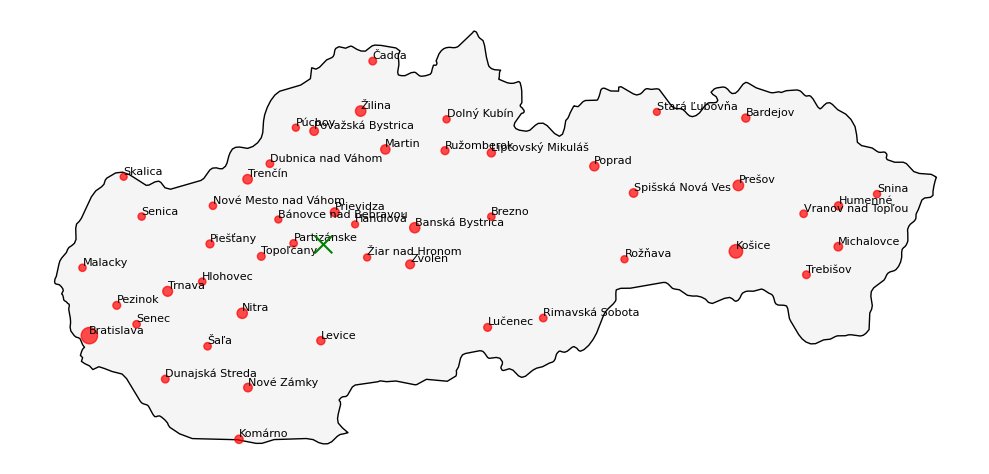

In [88]:
# x0 = np.array([
#     (DF_MESTA.geometry.x * DF_MESTA['Weight']).sum(),
#     (DF_MESTA.geometry.y * DF_MESTA['Weight']).sum()
# ])

# x0_1 = (DF_MESTA.geometry.x * DF_MESTA['Weight']).sum()
# x0_2 = (DF_MESTA.geometry.y * DF_MESTA['Weight']).sum()


# xk_1 = x0_1
# xk_2 = x0_2

# while True:
#     s1 = 0
#     s2 = 0
    
#     for i in range(M):
#         mesto = DF_MESTA.iloc[i]

#         di = ( (xk_1 - DF_MESTA.geometry.x)**2 + (xk_2 - DF_MESTA.geometry.y)**2 )**0.5

#         h_1 = mesto['Weight'] * mesto.geometry.x
#         h_2 = mesto['Weight'] * mesto.geometry.y


WC = WEIGHTS * COORDS
EPS = 10**-6

x0 = np.sum(WC, axis=0)
xk = x0.copy()
i = 0

while True:
    d = np.linalg.norm(xk-COORDS, axis=1)[:, None]

    # print(WC / d)
    xkk = np.sum(WC/d, axis=0) / np.sum(WEIGHTS / d)
    i += 1

    if np.linalg.norm(xkk - xk) < EPS:
        xk = xkk
        break

    xk = xkk

    

print(f'Finished in {i} iterations, found: {xk}')
plot_slovakia(xk)

# a = np.array([
#     [2**0.5,2**0.5],
#     [5,5]
# ])
# np.linalg.norm(a, axis=1)

# Uloha e)

Finished in 23 iterations, found [ -461684.93193385 -1236578.97489978]


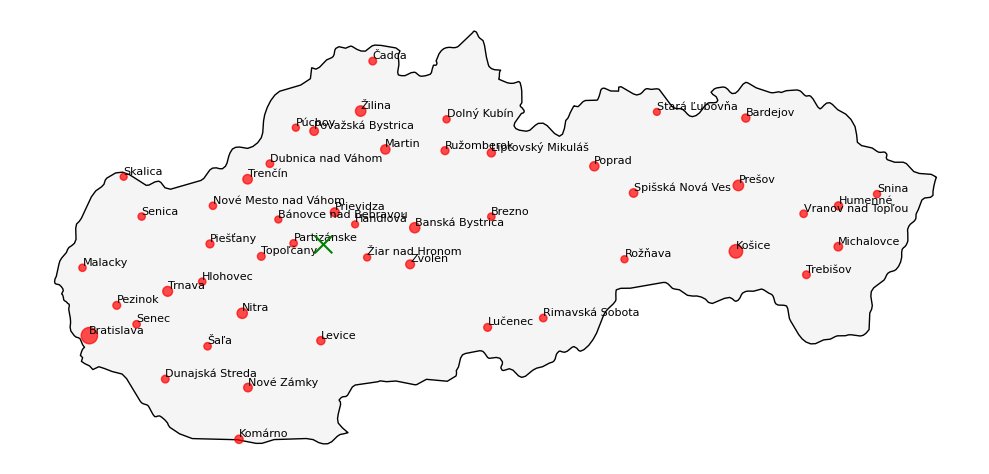

Step 10 finished in 100001 iterations, found [ -461344.91876848 -1236449.78273106]
Step 20 finished in 100001 iterations, found [ -461677.72575504 -1236576.22637112]
Step 40 finished in 72315 iterations, found [ -461684.89667723 -1236578.96145392]
Step 80 finished in 36155 iterations, found [ -461684.89670423 -1236578.96146422]
Step 160 finished in 18075 iterations, found [ -461684.89675826 -1236578.96148482]
Step 320 finished in 9035 iterations, found [ -461684.89686647 -1236578.96152609]
Step 640 finished in 4515 iterations, found [ -461684.89708353 -1236578.96160887]
Step 1280 finished in 2255 iterations, found [ -461684.89752017 -1236578.96177539]
Step 2560 finished in 1125 iterations, found [ -461684.89840352 -1236578.96211228]
Step 5120 finished in 560 iterations, found [ -461684.90021084 -1236578.96280154]
Step 10240 finished in 277 iterations, found [ -461684.89920838 -1236578.96241924]
Step 20480 finished in 136 iterations, found [ -461684.90751786 -1236578.96558823]
Step 4096

In [91]:
def gradient_basic(step, eps, max_itrs):
    WC = WEIGHTS * COORDS
    x0 = np.sum(WC, axis=0)
    xk = x0.copy()

    i = 0
    while True:
        d = np.linalg.norm(xk - COORDS, axis=1)[:, None]
        g = np.sum(WEIGHTS * (xk - COORDS) / d, axis=0)

        if np.linalg.norm(g) < eps or i > max_itrs:
            break

        xk = xk - g*step
        # print(g)
        i += 1
    
    return xk, i

x, i = gradient_basic(100_000, 10**-6, 100_000)
print(f'Finished in {i} iterations, found {x}')
plot_slovakia(x)

step = 10
while step < 10**7:
    x, i = gradient_basic(step, 10**-6, 100_000)
    print(f'Step {step} finished in {i} iterations, found {x}')
    step *= 2


